1단계: 데이터 로딩 & 포맷 인식
2단계 : 세션 시간 범위 밖의 데이터 제거
3단계: PPG 신호 전처리 (Signal Preprocessing)
-  Lowpass Filter (10Hz)
- Bandpass Filter (0.67-3.33Hz)

 4단계: HR 추정 (Heart Rate Estimation)
- IBI → HR 변환
- 1Hz Resampling
- Gap Masking

 5단계: 시간 정렬 (Temporal Alignment)
- Cross-Correlation 기반 정렬

6단계: 윈도우 필터링 (Window Filtering)
7단계: Metrics 계산

200Hz(C)와 25Hz(A)가 거의 동일한 HR 추정
MAE 1.23 bpm은 측정 불확실성 수준
Bias -0.23 bpm은 무시 가능

(장점)
주파수 차이 극복 (25Hz vs 200Hz)
-1Hz resampling으로 통일
-동일한 전처리 pipeline


시간 동기화
- Cross-correlation으로 자동 정렬
- Sub-second precision (+4초)

노이즈 robust
- Multi-stage filtering
- Gap masking
- Prominence-based peak detection


간헐 기록 대응
- A-block masking
- Valid second matching

1. Watch와 Ring의 공동구간 추출

PPG HR Alignment & Window Filtering
(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)
(Per-hour two windows: [24-30], [54-60])

Loaded files (raw):
  A: (153000, 6) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

Applying absolute-time cutting...
ABS window: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00
✓ A: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  153000 rows → 153000 rows
[build_datetime_series] col=sample_or_time, kind=epoch, unit=s, note=epoch s-ish (tmax=3.0e+10)
⚠ C: 절대시간 복원 실패/NaT 포함 → 절대시간 절단 생략

Loaded files (after abs-cut if applied):
  A: (153000, 6) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

[A-25Hz] HR Estimation Debug
Signal length: 153000 samples (6120.0 sec)
NaN values: 0 (0.00%)
Lowpass filter: Applied (10.0Hz)
Signal std: 24647.977
Base prominence: 4929.595
Min distance: 8 samples (0.32 sec)
Max distance: 75 samples (3.00 sec)
[build_datetime_series] col=sample_or_time, kind=epoch, unit=s, note=epoch s-ish (tmax=3.0e+10)

[C-200Hz] HR Estimation Debug
S

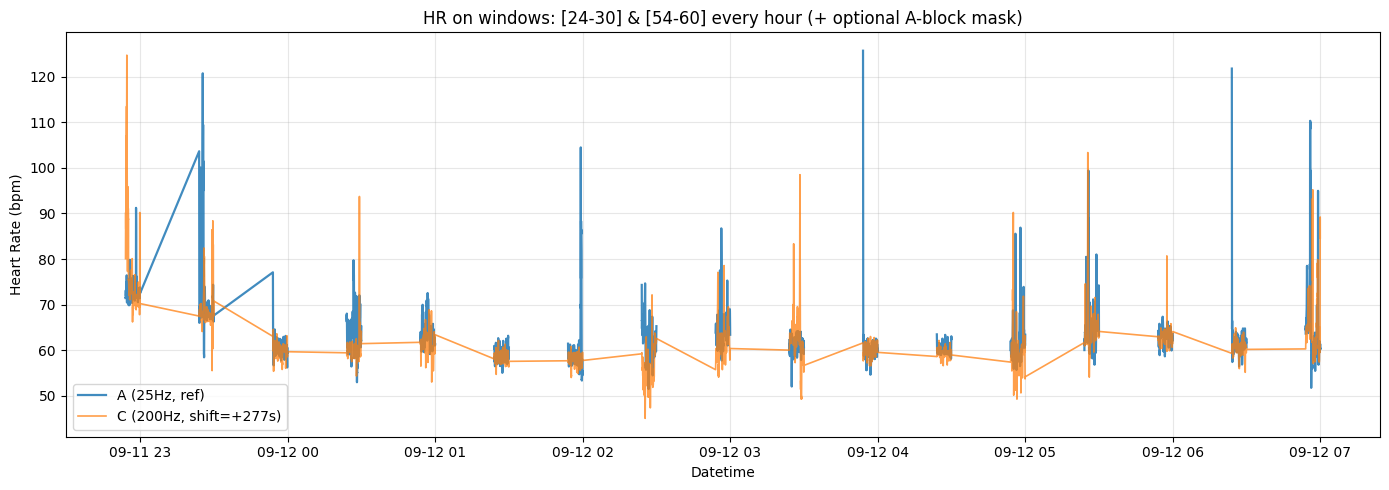


✓ Results saved to /content/drive/MyDrive/Colab Notebooks/RealPPG/


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 0) 사용자 설정
# =========================
file_a_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day1_cut_202509112247_202509120708.csv"
file_c_200 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"

FS_A = 25.0
FS_C = 200.0

MIN_BPM = 40
MAX_BPM = 200

# 매시간 2번 윈도우: 24~30분, 54~정각(60분)
WINDOW_PAIRS = ((24, 30), (54, 60))

# HR 추정 파라미터
PROM_SCALE = 0.2
SMOOTH_WIN = 5
MAX_INTERP_GAP_SEC = 8.0

# 전처리 파라미터 (공통 적용)
APPLY_LOWPASS = True
LOWPASS_CUTOFF_HZ = 10.0

# 정렬 파라미터
ALIGN_DURATION_SEC = 2 * 3600
MAX_SHIFT_SEC = 30 * 60

DEBUG_MODE = True

# 절대시간 기반 절단(세션 시작/종료)
CUT_BY_ABS_TIME = True
ABS_START_DT = "2025-09-11 22:47:00"
ABS_END_DT   = "2025-09-12 07:08:00"

# 6분 블록(간헐 기록) 감안
USE_A_BLOCK_MASK = True


# ============================================================
# 1) CSV 로딩/컬럼 추정
# ============================================================
def read_csv_robust(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except Exception:
            return False

    # 헤더가 숫자처럼 보이면 header=None으로 재로딩
    if df.shape[1] >= 2 and all(is_numberish(c) for c in df.columns):
        df = pd.read_csv(path, header=None)

    # 2컬럼이면 (time_like, ppg)로 가정
    if df.shape[1] == 2:
        df.columns = ["sample_or_time", "ppg"]

    return df


def infer_ppg_col(df: pd.DataFrame) -> str:
    if "ppg" in df.columns:
        return "ppg"

    # numeric 변환 시도
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    exclude = set([
        "sample_index_25hz", "sample_index_200hz", "sample_index", "index", "Index",
        "timestamp", "sample_or_time", "time", "Time", "today", "date", "Date",
        "acc_x", "acc_y", "acc_z"  # 가속도계 컬럼 제외
    ])
    num_cols = [c for c in num_cols if c not in exclude]

    if len(num_cols) == 0:
        raise ValueError("PPG 컬럼을 찾지 못했습니다. 컬럼명을 확인해 주세요.")
    return num_cols[-1]


def pick_time_col(df: pd.DataFrame):
    """
    시간컬럼 후보 우선순위:
      1) time (datetime 문자열)
      2) timestamp (epoch ms)
      3) sample_or_time
      4) 이름에 time/stamp/tick 포함된 컬럼
      5) (fallback) 단조증가하는 숫자 컬럼
    """
    cols = list(df.columns)

    # time 컬럼이 있고 datetime으로 파싱 가능하면 우선
    if "time" in cols:
        try:
            test = pd.to_datetime(df["time"].iloc[:10], errors="coerce")
            if test.notna().sum() >= 5:
                return "time"
        except Exception:
            pass

    if "timestamp" in cols:
        return "timestamp"
    if "sample_or_time" in cols:
        return "sample_or_time"

    # 이름 기반
    for c in cols:
        cl = str(c).lower()
        if ("time" in cl) or ("stamp" in cl) or ("tick" in cl):
            return c

    # numeric 변환
    for c in cols:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

    best = None
    best_score = -1e18
    for c in num_cols:
        x = df[c].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        if len(x) < 50:
            continue
        d = np.diff(x)
        inc_ratio = np.mean(d >= 0)
        # 완전 단조증가에 가까운 컬럼 선호
        score = inc_ratio
        if score > best_score:
            best_score = score
            best = c

    if best is not None and best_score > 0.95:
        return best
    return None


# ============================================================
# 2) timestamp 단위/형태 추정 (epoch vs relative, us/ms/s/index)
#   + sample_index류는 강제로 index 처리
# ============================================================
def infer_time_scale_from_timestamp(ts: np.ndarray, colname: str = "", fs_hint: float = None):
    ts = np.asarray(ts, dtype=float)
    ts = ts[np.isfinite(ts)]
    if len(ts) < 3:
        return ("relative", "index", None, "too_few_ts -> index")

    col_l = str(colname).lower()
    if ("sample_index" in col_l) or (col_l in ["index", "idx"]) or col_l.endswith("_index"):
        return ("relative", "index", None, f"forced index by colname={colname}")

    d = np.diff(ts)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return ("relative", "index", None, "too_few_diff -> index")

    dmed = float(np.median(d))
    tmax = float(np.max(ts))
    tmin = float(np.min(ts))

    # epoch-like magnitude
    if tmax > 1e14:
        if dmed > 1e8:
            return ("epoch", "ns", None, f"epoch ns (dmed={dmed:.1f})")
        elif dmed > 1e5:
            return ("epoch", "us", None, f"epoch us (dmed={dmed:.1f})")
        elif dmed > 1e2:
            return ("epoch", "ms", None, f"epoch ms (dmed={dmed:.1f})")
        else:
            return ("epoch", "s", None, f"epoch s (dmed={dmed:.1f})")

    if 1e11 < tmax <= 1e14:
        return ("epoch", "ms", None, f"epoch ms-ish (tmax={tmax:.1e})")

    if 1e8 < tmax <= 1e11:
        return ("epoch", "s", None, f"epoch s-ish (tmax={tmax:.1e})")

    # relative: 200Hz라면 us:~5000, ms:~5, s:~0.005, index:~1
    if 0.5 <= dmed <= 2.0:
        return ("relative", "index", None, f"relative index-like (dmed={dmed:.3f})")

    cand = []
    if dmed > 0:
        cand.append(("us", 1e6 / dmed))
        cand.append(("ms", 1e3 / dmed))
        cand.append(("s", 1.0 / dmed))

    def score(fs):
        if fs <= 0:
            return -1e9
        base = -abs(fs - 200.0)
        # fs_hint가 있으면 그쪽도 약간 반영
        if fs_hint is not None:
            base += -0.2 * abs(fs - fs_hint)
        return base

    best = None
    best_score = -1e18
    for unit, fs_est in cand:
        if 5 <= fs_est <= 5000:
            sc = score(fs_est)
            if sc > best_score:
                best_score = sc
                best = (unit, fs_est)

    if best is None:
        if dmed > 1000:
            return ("relative", "us", 1e6, f"relative us fallback (dmed={dmed:.1f})")
        elif dmed > 1:
            return ("relative", "ms", 1e3, f"relative ms fallback (dmed={dmed:.3f})")
        else:
            return ("relative", "s", 1.0, f"relative s fallback (dmed={dmed:.6f})")

    unit, fs_est = best
    to_div = {"us": 1e6, "ms": 1e3, "s": 1.0}[unit]
    return ("relative", unit, to_div, f"relative {unit} (fs_est≈{fs_est:.1f}Hz, dmed={dmed:.3f}, range=[{tmin:.1f},{tmax:.1f}])")


# ============================================================
# 3) 절대시간(datetime) & 절대초(t_abs_sec) 만들기
#   - relative timestamp는 ts 자체를 경과시간으로 사용(중요)
# ============================================================
def build_datetime_series(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> pd.Series:
    # 우선순위 1: time 컬럼 (datetime 문자열)
    if "time" in df.columns:
        dt = pd.to_datetime(df["time"], errors="coerce")
        if dt.notna().sum() >= 3:
            return pd.Series(dt)

    # 우선순위 2: today/time 조합
    if ("today" in df.columns) and ("time" in df.columns):
        dt = pd.to_datetime(df["today"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        if dt.notna().sum() >= 3:
            return pd.Series(dt)

    tc = pick_time_col(df)
    if tc is None:
        return pd.Series([pd.NaT] * len(df))

    ts = pd.to_numeric(df[tc], errors="coerce").to_numpy(dtype=float)
    if np.isfinite(ts).sum() < 3:
        return pd.Series([pd.NaT] * len(df))

    kind, unit, to_div, note = infer_time_scale_from_timestamp(ts, colname=tc, fs_hint=fs)
    if DEBUG_MODE:
        print(f"[build_datetime_series] col={tc}, kind={kind}, unit={unit}, note={note}")

    if kind == "epoch":
        return pd.Series(pd.to_datetime(ts, unit=unit, errors="coerce"))

    # relative
    if unit == "index":
        elapsed = np.arange(len(df), dtype=float) / fs
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)
    else:
        # ★ ts 자체를 경과시간으로 사용
        elapsed = ts / to_div
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)


def build_time_abs_seconds(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> np.ndarray:
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.notna().all():
        delta = (dt - anchor_dt)
        # 안전한 초 변환
        sec = delta.dt.total_seconds().to_numpy()
        return sec.astype(float)

    return (np.arange(len(df), dtype=float) / fs).astype(float)


def cut_by_abs_time(df: pd.DataFrame, fs: float, start_dt: pd.Timestamp, end_dt: pd.Timestamp,
                    label: str, anchor_dt: pd.Timestamp):
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.isna().any():
        print(f"⚠ {label}: 절대시간 복원 실패/NaT 포함 → 절대시간 절단 생략")
        return df

    m = (dt >= start_dt) & (dt <= end_dt)
    out = df.loc[m].reset_index(drop=True)
    print(f"✓ {label}: ABS-CUT {start_dt} ~ {end_dt}  |  {len(df)} rows → {len(out)} rows")
    return out


# ============================================================
# 4) 전처리
# ============================================================
def apply_lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        print("⚠ WARNING: scipy not available, skipping lowpass filter")
        return x


def bandpass_ppg(x: np.ndarray, fs: float, f_lo: float, f_hi: float, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt, detrend
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max(f_lo / nyq, 1e-6)
        hi = min(f_hi / nyq, 0.999)
        b, a = butter(order, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except Exception:
        w = int(max(1, round(fs * 0.8)))
        baseline = pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()
        return x - baseline


def preprocess_ppg(x: np.ndarray, fs: float,
                   apply_lowpass: bool = True,
                   lowpass_cutoff_hz: float = 10.0) -> np.ndarray:
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if apply_lowpass:
        x = apply_lowpass_filter(x, fs, cutoff_hz=lowpass_cutoff_hz, order=4)

    return bandpass_ppg(x, fs, f_lo=MIN_BPM/60.0, f_hi=MAX_BPM/60.0, order=4)


# ============================================================
# 5) HR(1Hz) 추정 (t_abs_sec 사용)
# ============================================================
def estimate_hr_1hz_gapmasked(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp,
                              max_interp_gap_sec: float,
                              file_label: str = "",
                              apply_lowpass: bool = True,
                              lowpass_cutoff_hz: float = 10.0) -> pd.DataFrame:
    ppg_col = infer_ppg_col(df)
    t_abs = build_time_abs_seconds(df, fs, anchor_dt)

    x = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    nan_count = np.sum(~np.isfinite(x))

    x_f = preprocess_ppg(x, fs, apply_lowpass=apply_lowpass, lowpass_cutoff_hz=lowpass_cutoff_hz)

    min_dist = int(round((60.0 / MAX_BPM) * fs))
    max_dist = int(round((60.0 / MIN_BPM) * fs * 2.0))
    base_prominence = PROM_SCALE * np.std(x_f)

    if DEBUG_MODE:
        print(f"\n{'='*60}")
        print(f"[{file_label}] HR Estimation Debug")
        print(f"{'='*60}")
        print(f"Signal length: {len(x_f)} samples ({len(x_f)/fs:.1f} sec)")
        print(f"NaN values: {nan_count} ({100*nan_count/len(x):.2f}%)")
        print(f"Lowpass filter: {'Applied' if apply_lowpass else 'Skipped'} ({lowpass_cutoff_hz}Hz)")
        print(f"Signal std: {np.std(x_f):.3f}")
        print(f"Base prominence: {base_prominence:.3f}")
        print(f"Min distance: {min_dist} samples ({min_dist/fs:.2f} sec)")
        print(f"Max distance: {max_dist} samples ({max_dist/fs:.2f} sec)")

    try:
        from scipy.signal import find_peaks
        peaks, props = find_peaks(x_f,
                                  distance=max(1, min_dist),
                                  prominence=base_prominence,
                                  width=max(1, min_dist//3))

        # 너무 먼 peak 제거
        if len(peaks) > 1:
            peak_dists = np.diff(peaks)
            valid_peaks = [peaks[0]]
            for i, d in enumerate(peak_dists):
                if d <= max_dist:
                    valid_peaks.append(peaks[i+1])
            peaks = np.array(valid_peaks)

            if DEBUG_MODE and len(peaks) < len(props['prominences']):
                print(f"Removed {len(props['prominences']) - len(peaks)} peaks exceeding max_dist")

    except Exception as e:
        print(f"Peak detection failed: {e}")
        peaks = []
        for i in range(1, len(x_f) - 1):
            if x_f[i-1] < x_f[i] and x_f[i] > x_f[i+1]:
                peaks.append(i)
        peaks = np.array(peaks, dtype=int)

    if len(peaks) < 2:
        print(f"ERROR: Too few peaks ({len(peaks)})!")
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    tp = t_abs[peaks]
    ibi = np.diff(tp)

    hr = 60.0 / ibi
    th = tp[1:]

    valid = np.isfinite(hr) & (hr >= MIN_BPM) & (hr <= MAX_BPM)
    hr = hr[valid]
    th = th[valid]

    if len(hr) < 2:
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    # 1Hz grid (anchor 기준 절대초)
    t1 = np.arange(np.ceil(th.min()), np.floor(th.max()) + 1e-9, 1.0)
    hr1 = np.full_like(t1, np.nan, dtype=float)

    gaps = np.diff(th)
    cut = np.where(gaps > max_interp_gap_sec)[0]
    starts = np.r_[0, cut + 1]
    ends   = np.r_[cut, len(th) - 1]

    for s, e in zip(starts, ends):
        if e - s < 1:
            continue
        t_start, t_end = th[s], th[e]
        m = (t1 >= t_start) & (t1 <= t_end)
        if m.sum() == 0:
            continue
        hr1[m] = np.interp(t1[m], th[s:e+1], hr[s:e+1])

    if SMOOTH_WIN and SMOOTH_WIN > 1:
        hr1 = pd.Series(hr1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().to_numpy()

    return pd.DataFrame({"t_sec": t1, "hr_bpm": hr1})


# ============================================================
# 6) HR 기반 shift 최적화
# ============================================================
def best_shift_by_corr_nanaware(hr_ref: pd.DataFrame, hr_tar: pd.DataFrame,
                                align_duration_sec: int, max_shift_sec: int):
    if len(hr_ref) < 60 or len(hr_tar) < 60:
        return 0, np.nan

    T = int(align_duration_sec)
    grid = np.arange(0, T + 1, 1.0)

    ref = np.interp(grid, hr_ref["t_sec"], hr_ref["hr_bpm"], left=np.nan, right=np.nan)
    tar = np.interp(grid, hr_tar["t_sec"], hr_tar["hr_bpm"], left=np.nan, right=np.nan)

    m = np.isfinite(ref) & np.isfinite(tar)
    if m.sum() < 300:
        return 0, np.nan

    ref_valid = ref[m]
    tar_valid = tar[m]
    ref_mean, ref_std = np.mean(ref_valid), np.std(ref_valid)
    tar_mean, tar_std = np.mean(tar_valid), np.std(tar_valid)

    refZ = np.where(m, (ref - ref_mean) / (ref_std + 1e-9), np.nan)
    tarZ = np.where(m, (tar - tar_mean) / (tar_std + 1e-9), np.nan)

    best_s, best_r = 0, -1e9

    if DEBUG_MODE:
        print(f"\n[Alignment] Searching shift range: [{-max_shift_sec}, {max_shift_sec}]s")
        print(f"[Alignment] Valid overlap points: {m.sum()}/{len(grid)}")

    for s in range(-max_shift_sec, max_shift_sec + 1):
        if s >= 0:
            rr = refZ[s:]
            tt = tarZ[:len(rr)]
        else:
            rr = refZ[:len(refZ)+s]
            tt = tarZ[-s:]

        v = np.isfinite(rr) & np.isfinite(tt)
        if v.sum() < 300:
            continue

        # Constant signal check
        if np.std(rr[v]) < 1e-6 or np.std(tt[v]) < 1e-6:
            continue

        r = float(np.corrcoef(rr[v], tt[v])[0, 1])

        # Extra safety for NaN
        if np.isnan(r):
            continue

        if r > best_r:
            best_r, best_s = r, s

    return best_s, best_r


# ============================================================
# 7) 윈도우 생성/필터
# ============================================================
def make_two_windows_per_hour(dt_start: pd.Timestamp, dt_end: pd.Timestamp,
                              pairs=((24, 30), (54, 60))):
    floor_hour = dt_start.floor("h") - pd.Timedelta(hours=1)
    ceil_hour  = dt_end.ceil("h") + pd.Timedelta(hours=1)

    hours = pd.date_range(floor_hour, ceil_hour, freq="h")
    windows = []
    for h in hours:
        for (m0, m1) in pairs:
            w_start = h + pd.Timedelta(minutes=int(m0))
            w_end = (h + pd.Timedelta(hours=1)) if int(m1) >= 60 else (h + pd.Timedelta(minutes=int(m1)))
            if w_end <= dt_start or w_start >= dt_end:
                continue
            windows.append((max(w_start, dt_start), min(w_end, dt_end)))
    return sorted(windows, key=lambda x: x[0])


def filter_by_windows(hr_df: pd.DataFrame, anchor_dt: pd.Timestamp, windows):
    if len(hr_df) == 0:
        return hr_df
    out = hr_df.copy()
    out["dt"] = anchor_dt + pd.to_timedelta(out["t_sec"], unit="s")

    mask = pd.Series(False, index=out.index)
    for ws, we in windows:
        mask |= (out["dt"] >= ws) & (out["dt"] < we)
    return out.loc[mask].reset_index(drop=True)


def apply_a_block_mask(hr_df: pd.DataFrame, valid_sec: np.ndarray):
    if len(hr_df) == 0:
        return hr_df
    sec = np.round(hr_df["t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.asarray(valid_sec, dtype=np.int64)
    mask = np.isin(sec, valid_sec)
    return hr_df.loc[mask].reset_index(drop=True)


# ============================================================
# 8) 실행
# ============================================================
anchor_dt = pd.to_datetime(ABS_START_DT)
start_dt = pd.to_datetime(ABS_START_DT)
end_dt   = pd.to_datetime(ABS_END_DT)

print("="*60)
print("PPG HR Alignment & Window Filtering")
print("(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)")
print("(Per-hour two windows: [24-30], [54-60])")
print("="*60)

dfa = read_csv_robust(file_a_25)
dfc = read_csv_robust(file_c_200)

print(f"\nLoaded files (raw):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

if CUT_BY_ABS_TIME:
    print(f"\n{'='*60}")
    print("Applying absolute-time cutting...")
    print(f"ABS window: {start_dt} ~ {end_dt}")
    print(f"{'='*60}")

    dfa = cut_by_abs_time(dfa, FS_A, start_dt, end_dt, "A", anchor_dt)
    dfc = cut_by_abs_time(dfc, FS_C, start_dt, end_dt, "C", anchor_dt)

print(f"\nLoaded files (after abs-cut if applied):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

# HR 추정 (t_sec는 anchor_dt 기준 절대초)
hr_a = estimate_hr_1hz_gapmasked(dfa, FS_A, anchor_dt, MAX_INTERP_GAP_SEC, "A-25Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)
hr_c = estimate_hr_1hz_gapmasked(dfc, FS_C, anchor_dt, MAX_INTERP_GAP_SEC, "C-200Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

if len(hr_a) == 0 or len(hr_c) == 0:
    raise RuntimeError("HR 추정 결과가 비었습니다. (A/C 중 하나)")

print(f"\n{'='*60}")
print("Computing time alignment...")
print(f"{'='*60}")

shift_c, corr_c = best_shift_by_corr_nanaware(hr_a, hr_c, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)

print(f"\n[Result] C alignment: shift={shift_c:+.0f}s, corr={corr_c:.3f}")

hr_c_aligned = hr_c.copy()
hr_c_aligned["t_sec"] = hr_c_aligned["t_sec"] + shift_c

# 윈도우 생성: 실제 절대시간 범위로 제한
dt_a_start = anchor_dt + pd.to_timedelta(float(np.nanmin(hr_a["t_sec"])), unit="s")
dt_a_end   = anchor_dt + pd.to_timedelta(float(np.nanmax(hr_a["t_sec"])), unit="s")
dt_a_start = max(dt_a_start, start_dt)
dt_a_end   = min(dt_a_end, end_dt)

print(f"\n{'='*60}")
print("Generating time windows...")
print(f"{'='*60}")
print(f"Time range: {dt_a_start} to {dt_a_end}")

windows = make_two_windows_per_hour(dt_a_start, dt_a_end, pairs=WINDOW_PAIRS)
print(f"Generated {len(windows)} windows per-hour pairs={WINDOW_PAIRS}")
if windows:
    print(f"First window: {windows[0]}")
    print(f"Last window:  {windows[-1]}")

# 윈도우 필터 적용
fa = filter_by_windows(hr_a, anchor_dt, windows)
fc = filter_by_windows(hr_c_aligned, anchor_dt, windows)

# A의 유효초만 C에도 적용
if USE_A_BLOCK_MASK:
    valid_sec = np.round(fa.loc[fa["hr_bpm"].notna(), "t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.unique(valid_sec)
    fc = apply_a_block_mask(fc, valid_sec)
    if DEBUG_MODE:
        print(f"\n[6-min block masking] A-valid seconds: {len(valid_sec)} points")
        print(f"[6-min block masking] After mask: C={len(fc)}")

print(f"\n{'='*60}")
print("Final Results")
print(f"{'='*60}")
print(f"  A: {fa['hr_bpm'].notna().sum():5d} / {len(fa):5d} ({100*fa['hr_bpm'].notna().mean():.1f}%)")
print(f"  C: {fc['hr_bpm'].notna().sum():5d} / {len(fc):5d} ({100*fc['hr_bpm'].notna().mean():.1f}%)")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(fa["dt"], fa["hr_bpm"], label="A (25Hz, ref)", alpha=0.85, linewidth=1.6)
plt.plot(fc["dt"], fc["hr_bpm"], label=f"C (200Hz, shift={shift_c:+.0f}s)", alpha=0.75, linewidth=1.2)
plt.xlabel("Datetime")
plt.ylabel("Heart Rate (bpm)")
plt.title("HR on windows: [24-30] & [54-60] every hour (+ optional A-block mask)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save
output_dir = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"
suffix = "win_24-30_54-60"
if USE_A_BLOCK_MASK:
    suffix += "_Ablock"

fa.to_csv(output_dir + f"HR_final_A_25_{suffix}.csv", index=False)
fc.to_csv(output_dir + f"HR_final_C_200_{suffix}_shift{shift_c:+.0f}s.csv", index=False)

print(f"\n✓ Results saved to {output_dir}")

PPG HR Alignment & Window Filtering
(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)
(Per-hour two windows: [24-30], [54-60])

Loaded files (raw):
  A: (153000, 6) @ 25.0Hz
  C: (6066288, 2) @ 200.0Hz

Applying absolute-time cutting...
ABS window: 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00
✓ A: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  153000 rows → 153000 rows
[build_datetime_series] col=sample_or_time, kind=relative, unit=us, note=relative us (fs_est≈186.8Hz, dmed=5352.000, range=30107152346.0 us)
✓ C: ABS-CUT 2025-09-11 22:47:00 ~ 2025-09-12 07:08:00  |  6066288 rows → 6056593 rows

Loaded files (after abs-cut if applied):
  A: (153000, 6) @ 25.0Hz
  C: (6056593, 2) @ 200.0Hz

[A-25Hz] HR Estimation Debug
Signal length: 153000 samples (6120.0 sec)
NaN values: 0 (0.00%)
Lowpass filter: Applied (10.0Hz)
Signal std: 24647.977
Base prominence: 4929.595
Min distance: 8 samples (0.32 sec)
Max distance: 75 samples (3.00 sec)
[build_datetime_series] col=samp

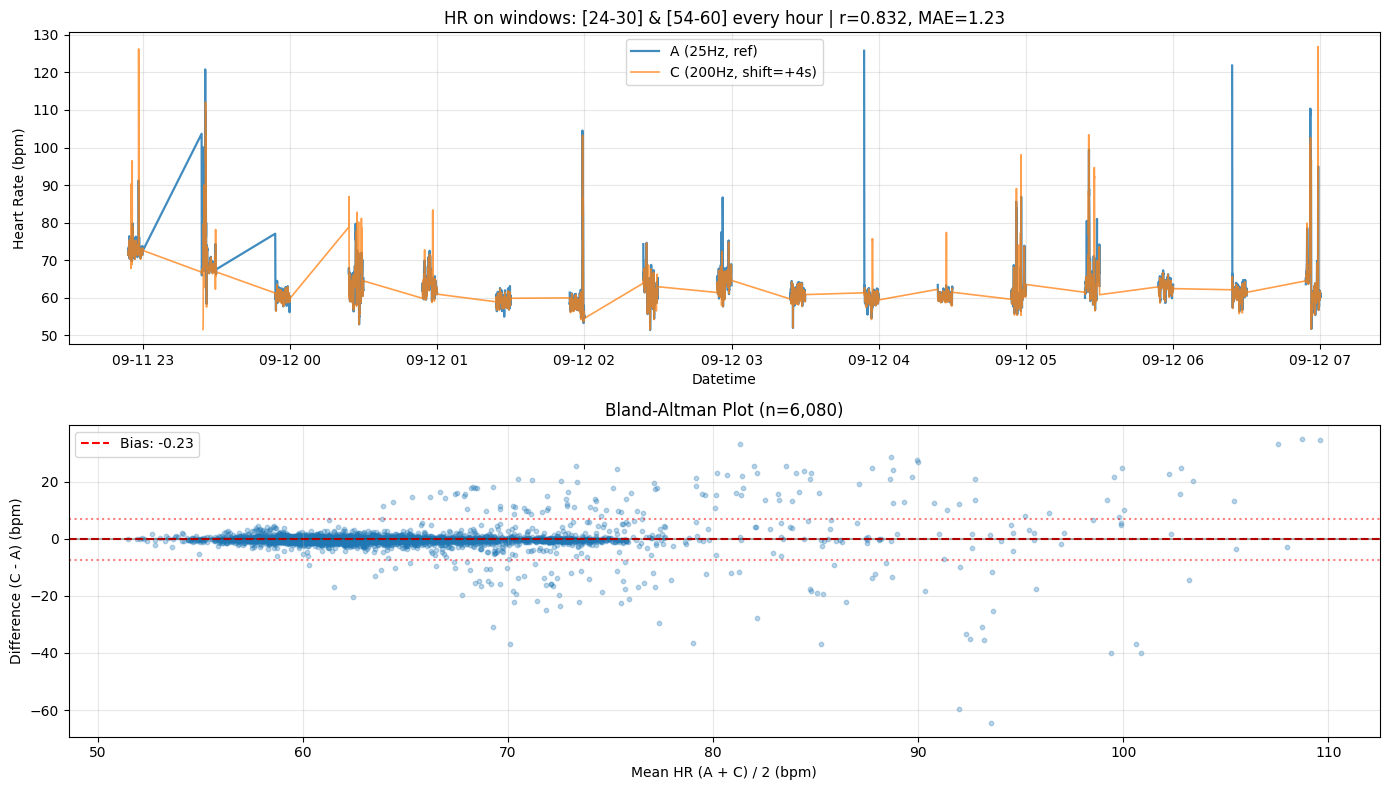


✓ Results saved to /content/drive/MyDrive/Colab Notebooks/RealPPG/
  - HR_final_A_25_win_24-30_54-60_Ablock.csv
  - HR_final_C_200_win_24-30_54-60_Ablock_shift+4s.csv
  - metrics_win_24-30_54-60_Ablock.csv


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 0) 사용자 설정
# =========================
file_a_25 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/E0001_Day1_cut_202509112247_202509120708.csv"
file_c_200 = "/content/drive/MyDrive/Colab Notebooks/RealPPG/ppgRaw.csv"

FS_A = 25.0
FS_C = 200.0

MIN_BPM = 40
MAX_BPM = 200

# 매시간 2번 윈도우: 24~30분, 54~정각(60분)
WINDOW_PAIRS = ((24, 30), (54, 60))

# HR 추정 파라미터
PROM_SCALE = 0.2
SMOOTH_WIN = 5
MAX_INTERP_GAP_SEC = 8.0

# 전처리 파라미터 (공통 적용)
APPLY_LOWPASS = True
LOWPASS_CUTOFF_HZ = 10.0

# 정렬 파라미터
ALIGN_DURATION_SEC = 2 * 3600
MAX_SHIFT_SEC = 30 * 60

DEBUG_MODE = True

# 절대시간 기반 절단(세션 시작/종료)
CUT_BY_ABS_TIME = True
ABS_START_DT = "2025-09-11 22:47:00"
ABS_END_DT   = "2025-09-12 07:08:00"

# 6분 블록(간헐 기록) 감안
USE_A_BLOCK_MASK = True

# Merge tolerance for MAE calculation
MERGE_TOLERANCE_SEC = 1.0


# ============================================================
# 1) CSV 로딩/컬럼 추정
# ============================================================
def read_csv_robust(path: str) -> pd.DataFrame:
    """
    CSV 로딩 with 헤더 자동 감지
    """
    # 일단 읽어보기
    df_test = pd.read_csv(path, nrows=5)

    def is_numberish(x):
        try:
            float(str(x).strip())
            return True
        except Exception:
            return False

    # 헤더가 모두 숫자처럼 보이면 header=None으로 재로딩
    if df_test.shape[1] >= 2 and all(is_numberish(c) for c in df_test.columns):
        df = pd.read_csv(path, header=None)

        # 2컬럼이면 (time_like, ppg)로 가정
        if df.shape[1] == 2:
            df.columns = ["sample_or_time", "ppg"]
    else:
        df = pd.read_csv(path)
        # 2컬럼이면 (time_like, ppg)로 가정
        if df.shape[1] == 2 and "ppg" not in df.columns:
            df.columns = ["sample_or_time", "ppg"]

    return df


def infer_ppg_col(df: pd.DataFrame) -> str:
    if "ppg" in df.columns:
        return "ppg"

    # numeric 변환 시도
    for c in df.columns:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

    exclude = set([
        "sample_index_25hz", "sample_index_200hz", "sample_index", "index", "Index",
        "timestamp", "sample_or_time", "time", "Time", "today", "date", "Date",
        "acc_x", "acc_y", "acc_z"  # 가속도계 컬럼 제외
    ])
    num_cols = [c for c in num_cols if c not in exclude]

    if len(num_cols) == 0:
        raise ValueError("PPG 컬럼을 찾지 못했습니다. 컬럼명을 확인해 주세요.")
    return num_cols[-1]


def pick_time_col(df: pd.DataFrame):
    """
    시간컬럼 후보 우선순위:
      1) time (datetime 문자열)
      2) timestamp (epoch ms)
      3) sample_or_time
      4) 이름에 time/stamp/tick 포함된 컬럼
      5) (fallback) 단조증가하는 숫자 컬럼
    """
    cols = list(df.columns)

    # time 컬럼이 있고 datetime으로 파싱 가능하면 우선
    if "time" in cols:
        try:
            test = pd.to_datetime(df["time"].iloc[:10], errors="coerce")
            if test.notna().sum() >= 5:
                return "time"
        except Exception:
            pass

    if "timestamp" in cols:
        return "timestamp"
    if "sample_or_time" in cols:
        return "sample_or_time"

    # 이름 기반
    for c in cols:
        cl = str(c).lower()
        if ("time" in cl) or ("stamp" in cl) or ("tick" in cl):
            return c

    # numeric 변환
    for c in cols:
        try:
            df[c] = pd.to_numeric(df[c])
        except Exception:
            pass

    num_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]

    best = None
    best_score = -1e18
    for c in num_cols:
        x = df[c].to_numpy(dtype=float)
        x = x[np.isfinite(x)]
        if len(x) < 50:
            continue
        d = np.diff(x)
        inc_ratio = np.mean(d >= 0)
        # 완전 단조증가에 가까운 컬럼 선호
        score = inc_ratio
        if score > best_score:
            best_score = score
            best = c

    if best is not None and best_score > 0.95:
        return best
    return None


# ============================================================
# 2) timestamp 단위/형태 추정 (epoch vs relative, us/ms/s/index)
#   + sample_index류는 강제로 index 처리
# ============================================================
def infer_time_scale_from_timestamp(ts: np.ndarray, colname: str = "", fs_hint: float = None):
    ts = np.asarray(ts, dtype=float)
    ts = ts[np.isfinite(ts)]
    if len(ts) < 3:
        return ("relative", "index", None, "too_few_ts -> index")

    col_l = str(colname).lower()
    if ("sample_index" in col_l) or (col_l in ["index", "idx"]) or col_l.endswith("_index"):
        return ("relative", "index", None, f"forced index by colname={colname}")

    d = np.diff(ts)
    d = d[np.isfinite(d)]
    if len(d) < 2:
        return ("relative", "index", None, "too_few_diff -> index")

    dmed = float(np.median(d))
    tmax = float(np.max(ts))
    tmin = float(np.min(ts))
    trange = tmax - tmin  # ★ 실제 시간 범위

    # epoch-like magnitude (절대시간) 판단
    # A 파일: timestamp ~ 1.75e12 (epoch ms), tmin도 1.75e12 수준
    # C 파일: timestamp ~ 3e7 (relative us), tmin은 작은 값

    # epoch 판단: tmin이 충분히 크면 epoch
    if tmin > 1e14:
        # nanoseconds
        return ("epoch", "ns", None, f"epoch ns (tmin={tmin:.1e}, dmed={dmed:.1f})")
    elif tmin > 1e11:
        # milliseconds or microseconds
        if dmed > 1e5:
            return ("epoch", "us", None, f"epoch us (tmin={tmin:.1e}, dmed={dmed:.1f})")
        else:
            return ("epoch", "ms", None, f"epoch ms (tmin={tmin:.1e}, dmed={dmed:.1f})")
    elif tmin > 1e8:
        # seconds
        return ("epoch", "s", None, f"epoch s (tmin={tmin:.1e}, dmed={dmed:.1f})")

    # relative (상대시간): tmin이 작고, trange가 합리적
    # 200Hz, 8시간 데이터 → us: ~2.88e10, ms: ~2.88e7, s: ~28800

    # index-like
    if 0.5 <= dmed <= 2.0:
        return ("relative", "index", None, f"relative index-like (dmed={dmed:.3f})")

    # us/ms/s 판단
    cand = []
    if dmed > 0:
        cand.append(("us", 1e6 / dmed))
        cand.append(("ms", 1e3 / dmed))
        cand.append(("s", 1.0 / dmed))

    def score(fs):
        if fs <= 0:
            return -1e9
        base = -abs(fs - 200.0)
        # fs_hint가 있으면 그쪽도 약간 반영
        if fs_hint is not None:
            base += -0.2 * abs(fs - fs_hint)
        return base

    best = None
    best_score = -1e18
    for unit, fs_est in cand:
        if 5 <= fs_est <= 5000:
            sc = score(fs_est)
            if sc > best_score:
                best_score = sc
                best = (unit, fs_est)

    if best is None:
        if dmed > 1000:
            return ("relative", "us", 1e6, f"relative us fallback (dmed={dmed:.1f})")
        elif dmed > 1:
            return ("relative", "ms", 1e3, f"relative ms fallback (dmed={dmed:.3f})")
        else:
            return ("relative", "s", 1.0, f"relative s fallback (dmed={dmed:.6f})")

    unit, fs_est = best
    to_div = {"us": 1e6, "ms": 1e3, "s": 1.0}[unit]
    return ("relative", unit, to_div, f"relative {unit} (fs_est≈{fs_est:.1f}Hz, dmed={dmed:.3f}, range={trange:.1f} {unit})")


# ============================================================
# 3) 절대시간(datetime) & 절대초(t_abs_sec) 만들기
#   - relative timestamp는 ts 자체를 경과시간으로 사용(중요)
# ============================================================
def build_datetime_series(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> pd.Series:
    # 우선순위 1: time 컬럼 (datetime 문자열)
    if "time" in df.columns:
        dt = pd.to_datetime(df["time"], errors="coerce")
        if dt.notna().sum() >= 3:
            return pd.Series(dt)

    # 우선순위 2: today/time 조합
    if ("today" in df.columns) and ("time" in df.columns):
        dt = pd.to_datetime(df["today"].astype(str) + " " + df["time"].astype(str), errors="coerce")
        if dt.notna().sum() >= 3:
            return pd.Series(dt)

    tc = pick_time_col(df)
    if tc is None:
        return pd.Series([pd.NaT] * len(df))

    ts = pd.to_numeric(df[tc], errors="coerce").to_numpy(dtype=float)
    if np.isfinite(ts).sum() < 3:
        return pd.Series([pd.NaT] * len(df))

    kind, unit, to_div, note = infer_time_scale_from_timestamp(ts, colname=tc, fs_hint=fs)
    if DEBUG_MODE:
        print(f"[build_datetime_series] col={tc}, kind={kind}, unit={unit}, note={note}")

    if kind == "epoch":
        return pd.Series(pd.to_datetime(ts, unit=unit, errors="coerce"))

    # relative (C 파일이 여기 해당)
    if unit == "index":
        elapsed = np.arange(len(df), dtype=float) / fs
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)
    else:
        # ★ ts 자체를 경과시간으로 사용 (us/ms/s로 나눔)
        # C 파일: ts는 0부터 시작하는 us tick
        elapsed = ts / to_div
        dt = anchor_dt + pd.to_timedelta(elapsed, unit="s")
        return pd.Series(dt)


def build_time_abs_seconds(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp) -> np.ndarray:
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.notna().all():
        delta = (dt - anchor_dt)
        # 안전한 초 변환
        sec = delta.dt.total_seconds().to_numpy()
        return sec.astype(float)

    return (np.arange(len(df), dtype=float) / fs).astype(float)


def cut_by_abs_time(df: pd.DataFrame, fs: float, start_dt: pd.Timestamp, end_dt: pd.Timestamp,
                    label: str, anchor_dt: pd.Timestamp):
    dt = build_datetime_series(df, fs, anchor_dt)
    if dt.isna().any():
        print(f"⚠ {label}: 절대시간 복원 실패/NaT 포함 → 절대시간 절단 생략")
        return df

    m = (dt >= start_dt) & (dt <= end_dt)
    out = df.loc[m].reset_index(drop=True)
    print(f"✓ {label}: ABS-CUT {start_dt} ~ {end_dt}  |  {len(df)} rows → {len(out)} rows")
    return out


# ============================================================
# 4) 전처리
# ============================================================
def apply_lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float = 10.0, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt
        nyq = 0.5 * fs
        wn = min(cutoff_hz / nyq, 0.99)
        b, a = butter(order, wn, btype="low")
        return filtfilt(b, a, x)
    except Exception:
        print("⚠ WARNING: scipy not available, skipping lowpass filter")
        return x


def bandpass_ppg(x: np.ndarray, fs: float, f_lo: float, f_hi: float, order: int = 4) -> np.ndarray:
    try:
        from scipy.signal import butter, filtfilt, detrend
        x0 = detrend(x)
        nyq = 0.5 * fs
        lo = max(f_lo / nyq, 1e-6)
        hi = min(f_hi / nyq, 0.999)
        b, a = butter(order, [lo, hi], btype="band")
        return filtfilt(b, a, x0)
    except Exception:
        w = int(max(1, round(fs * 0.8)))
        baseline = pd.Series(x).rolling(w, center=True, min_periods=1).mean().to_numpy()
        return x - baseline


def preprocess_ppg(x: np.ndarray, fs: float,
                   apply_lowpass: bool = True,
                   lowpass_cutoff_hz: float = 10.0) -> np.ndarray:
    if np.any(~np.isfinite(x)):
        x = pd.Series(x).interpolate(limit_direction="both").to_numpy(dtype=float)

    if apply_lowpass:
        x = apply_lowpass_filter(x, fs, cutoff_hz=lowpass_cutoff_hz, order=4)

    return bandpass_ppg(x, fs, f_lo=MIN_BPM/60.0, f_hi=MAX_BPM/60.0, order=4)


# ============================================================
# 5) HR(1Hz) 추정 (t_abs_sec 사용)
# ============================================================
def estimate_hr_1hz_gapmasked(df: pd.DataFrame, fs: float, anchor_dt: pd.Timestamp,
                              max_interp_gap_sec: float,
                              file_label: str = "",
                              apply_lowpass: bool = True,
                              lowpass_cutoff_hz: float = 10.0) -> pd.DataFrame:
    ppg_col = infer_ppg_col(df)
    t_abs = build_time_abs_seconds(df, fs, anchor_dt)

    x = pd.to_numeric(df[ppg_col], errors="coerce").to_numpy(dtype=float)
    nan_count = np.sum(~np.isfinite(x))

    x_f = preprocess_ppg(x, fs, apply_lowpass=apply_lowpass, lowpass_cutoff_hz=lowpass_cutoff_hz)

    min_dist = int(round((60.0 / MAX_BPM) * fs))
    max_dist = int(round((60.0 / MIN_BPM) * fs * 2.0))
    base_prominence = PROM_SCALE * np.std(x_f)

    if DEBUG_MODE:
        print(f"\n{'='*60}")
        print(f"[{file_label}] HR Estimation Debug")
        print(f"{'='*60}")
        print(f"Signal length: {len(x_f)} samples ({len(x_f)/fs:.1f} sec)")
        print(f"NaN values: {nan_count} ({100*nan_count/len(x):.2f}%)")
        print(f"Lowpass filter: {'Applied' if apply_lowpass else 'Skipped'} ({lowpass_cutoff_hz}Hz)")
        print(f"Signal std: {np.std(x_f):.3f}")
        print(f"Base prominence: {base_prominence:.3f}")
        print(f"Min distance: {min_dist} samples ({min_dist/fs:.2f} sec)")
        print(f"Max distance: {max_dist} samples ({max_dist/fs:.2f} sec)")

    try:
        from scipy.signal import find_peaks
        peaks, props = find_peaks(x_f,
                                  distance=max(1, min_dist),
                                  prominence=base_prominence,
                                  width=max(1, min_dist//3))

        # 너무 먼 peak 제거
        if len(peaks) > 1:
            peak_dists = np.diff(peaks)
            valid_peaks = [peaks[0]]
            for i, d in enumerate(peak_dists):
                if d <= max_dist:
                    valid_peaks.append(peaks[i+1])
            peaks = np.array(valid_peaks)

            if DEBUG_MODE and len(peaks) < len(props['prominences']):
                print(f"Removed {len(props['prominences']) - len(peaks)} peaks exceeding max_dist")

    except Exception as e:
        print(f"Peak detection failed: {e}")
        peaks = []
        for i in range(1, len(x_f) - 1):
            if x_f[i-1] < x_f[i] and x_f[i] > x_f[i+1]:
                peaks.append(i)
        peaks = np.array(peaks, dtype=int)

    if len(peaks) < 2:
        print(f"ERROR: Too few peaks ({len(peaks)})!")
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    tp = t_abs[peaks]
    ibi = np.diff(tp)

    hr = 60.0 / ibi
    th = tp[1:]

    valid = np.isfinite(hr) & (hr >= MIN_BPM) & (hr <= MAX_BPM)
    hr = hr[valid]
    th = th[valid]

    if len(hr) < 2:
        return pd.DataFrame({"t_sec": [], "hr_bpm": []})

    # 1Hz grid (anchor 기준 절대초)
    t1 = np.arange(np.ceil(th.min()), np.floor(th.max()) + 1e-9, 1.0)
    hr1 = np.full_like(t1, np.nan, dtype=float)

    gaps = np.diff(th)
    cut = np.where(gaps > max_interp_gap_sec)[0]
    starts = np.r_[0, cut + 1]
    ends   = np.r_[cut, len(th) - 1]

    for s, e in zip(starts, ends):
        if e - s < 1:
            continue
        t_start, t_end = th[s], th[e]
        m = (t1 >= t_start) & (t1 <= t_end)
        if m.sum() == 0:
            continue
        hr1[m] = np.interp(t1[m], th[s:e+1], hr[s:e+1])

    if SMOOTH_WIN and SMOOTH_WIN > 1:
        hr1 = pd.Series(hr1).rolling(SMOOTH_WIN, center=True, min_periods=1).mean().to_numpy()

    return pd.DataFrame({"t_sec": t1, "hr_bpm": hr1})


# ============================================================
# 6) HR 기반 shift 최적화
# ============================================================
def best_shift_by_corr_nanaware(hr_ref: pd.DataFrame, hr_tar: pd.DataFrame,
                                align_duration_sec: int, max_shift_sec: int):
    if len(hr_ref) < 60 or len(hr_tar) < 60:
        return 0, np.nan

    T = int(align_duration_sec)
    grid = np.arange(0, T + 1, 1.0)

    ref = np.interp(grid, hr_ref["t_sec"], hr_ref["hr_bpm"], left=np.nan, right=np.nan)
    tar = np.interp(grid, hr_tar["t_sec"], hr_tar["hr_bpm"], left=np.nan, right=np.nan)

    m = np.isfinite(ref) & np.isfinite(tar)
    if m.sum() < 300:
        return 0, np.nan

    ref_valid = ref[m]
    tar_valid = tar[m]
    ref_mean, ref_std = np.mean(ref_valid), np.std(ref_valid)
    tar_mean, tar_std = np.mean(tar_valid), np.std(tar_valid)

    refZ = np.where(m, (ref - ref_mean) / (ref_std + 1e-9), np.nan)
    tarZ = np.where(m, (tar - tar_mean) / (tar_std + 1e-9), np.nan)

    best_s, best_r = 0, -1e9

    if DEBUG_MODE:
        print(f"\n[Alignment] Searching shift range: [{-max_shift_sec}, {max_shift_sec}]s")
        print(f"[Alignment] Valid overlap points: {m.sum()}/{len(grid)}")

    for s in range(-max_shift_sec, max_shift_sec + 1):
        if s >= 0:
            rr = refZ[s:]
            tt = tarZ[:len(rr)]
        else:
            rr = refZ[:len(refZ)+s]
            tt = tarZ[-s:]

        v = np.isfinite(rr) & np.isfinite(tt)
        if v.sum() < 300:
            continue

        # Constant signal check
        if np.std(rr[v]) < 1e-6 or np.std(tt[v]) < 1e-6:
            continue

        r = float(np.corrcoef(rr[v], tt[v])[0, 1])

        # Extra safety for NaN
        if np.isnan(r):
            continue

        if r > best_r:
            best_r, best_s = r, s

    return best_s, best_r


# ============================================================
# 7) 윈도우 생성/필터
# ============================================================
def make_two_windows_per_hour(dt_start: pd.Timestamp, dt_end: pd.Timestamp,
                              pairs=((24, 30), (54, 60))):
    floor_hour = dt_start.floor("h") - pd.Timedelta(hours=1)
    ceil_hour  = dt_end.ceil("h") + pd.Timedelta(hours=1)

    hours = pd.date_range(floor_hour, ceil_hour, freq="h")
    windows = []
    for h in hours:
        for (m0, m1) in pairs:
            w_start = h + pd.Timedelta(minutes=int(m0))
            w_end = (h + pd.Timedelta(hours=1)) if int(m1) >= 60 else (h + pd.Timedelta(minutes=int(m1)))
            if w_end <= dt_start or w_start >= dt_end:
                continue
            windows.append((max(w_start, dt_start), min(w_end, dt_end)))
    return sorted(windows, key=lambda x: x[0])


def filter_by_windows(hr_df: pd.DataFrame, anchor_dt: pd.Timestamp, windows):
    if len(hr_df) == 0:
        return hr_df
    out = hr_df.copy()
    out["dt"] = anchor_dt + pd.to_timedelta(out["t_sec"], unit="s")

    mask = pd.Series(False, index=out.index)
    for ws, we in windows:
        mask |= (out["dt"] >= ws) & (out["dt"] < we)
    return out.loc[mask].reset_index(drop=True)


def apply_a_block_mask(hr_df: pd.DataFrame, valid_sec: np.ndarray):
    if len(hr_df) == 0:
        return hr_df
    sec = np.round(hr_df["t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.asarray(valid_sec, dtype=np.int64)
    mask = np.isin(sec, valid_sec)
    return hr_df.loc[mask].reset_index(drop=True)


# ============================================================
# 8) Metrics 계산
# ============================================================
def compute_metrics(df_a: pd.DataFrame, df_c: pd.DataFrame,
                   anchor_dt: pd.Timestamp, tolerance_sec: float = 1.0):
    """
    A와 C의 HR을 merge하여 correlation, MAE, RMSE, Bias 계산
    """
    if len(df_a) == 0 or len(df_c) == 0:
        return {
            'n_pairs': 0,
            'correlation': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'bias': np.nan
        }

    # dt 복원
    a_with_dt = df_a.copy()
    c_with_dt = df_c.copy()
    a_with_dt['dt'] = anchor_dt + pd.to_timedelta(a_with_dt['t_sec'], unit='s')
    c_with_dt['dt'] = anchor_dt + pd.to_timedelta(c_with_dt['t_sec'], unit='s')

    # Merge using pandas merge_asof (nearest matching within tolerance)
    a_sorted = a_with_dt[['dt', 'hr_bpm']].rename(columns={'hr_bpm': 'hr_a'}).sort_values('dt')
    c_sorted = c_with_dt[['dt', 'hr_bpm']].rename(columns={'hr_bpm': 'hr_c'}).sort_values('dt')

    merged = pd.merge_asof(
        a_sorted,
        c_sorted,
        on='dt',
        direction='nearest',
        tolerance=pd.Timedelta(seconds=tolerance_sec)
    )

    # Valid pairs만 선택
    valid = merged.dropna(subset=['hr_a', 'hr_c'])

    if len(valid) < 10:
        return {
            'n_pairs': len(valid),
            'correlation': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'bias': np.nan
        }

    hr_a = valid['hr_a'].to_numpy()
    hr_c = valid['hr_c'].to_numpy()

    # Correlation
    corr = np.corrcoef(hr_a, hr_c)[0, 1]

    # MAE, RMSE, Bias
    diff = hr_c - hr_a
    mae = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    bias = np.mean(diff)

    return {
        'n_pairs': len(valid),
        'correlation': float(corr),
        'mae': float(mae),
        'rmse': float(rmse),
        'bias': float(bias)
    }


# ============================================================
# 9) 실행
# ============================================================
anchor_dt = pd.to_datetime(ABS_START_DT)
start_dt = pd.to_datetime(ABS_START_DT)
end_dt   = pd.to_datetime(ABS_END_DT)

print("="*60)
print("PPG HR Alignment & Window Filtering")
print("(ABS anchor + timestamp(us/ms/s)/sample_index -> datetime restoration)")
print("(Per-hour two windows: [24-30], [54-60])")
print("="*60)

dfa = read_csv_robust(file_a_25)
dfc = read_csv_robust(file_c_200)

print(f"\nLoaded files (raw):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

if CUT_BY_ABS_TIME:
    print(f"\n{'='*60}")
    print("Applying absolute-time cutting...")
    print(f"ABS window: {start_dt} ~ {end_dt}")
    print(f"{'='*60}")

    dfa = cut_by_abs_time(dfa, FS_A, start_dt, end_dt, "A", anchor_dt)
    dfc = cut_by_abs_time(dfc, FS_C, start_dt, end_dt, "C", anchor_dt)

print(f"\nLoaded files (after abs-cut if applied):")
print(f"  A: {dfa.shape} @ {FS_A}Hz")
print(f"  C: {dfc.shape} @ {FS_C}Hz")

# HR 추정 (t_sec는 anchor_dt 기준 절대초)
hr_a = estimate_hr_1hz_gapmasked(dfa, FS_A, anchor_dt, MAX_INTERP_GAP_SEC, "A-25Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)
hr_c = estimate_hr_1hz_gapmasked(dfc, FS_C, anchor_dt, MAX_INTERP_GAP_SEC, "C-200Hz",
                                 apply_lowpass=APPLY_LOWPASS, lowpass_cutoff_hz=LOWPASS_CUTOFF_HZ)

if len(hr_a) == 0 or len(hr_c) == 0:
    raise RuntimeError("HR 추정 결과가 비었습니다. (A/C 중 하나)")

print(f"\n{'='*60}")
print("Computing time alignment...")
print(f"{'='*60}")

shift_c, corr_c = best_shift_by_corr_nanaware(hr_a, hr_c, ALIGN_DURATION_SEC, MAX_SHIFT_SEC)

print(f"\n[Result] C alignment: shift={shift_c:+.0f}s, corr={corr_c:.3f}")

hr_c_aligned = hr_c.copy()
hr_c_aligned["t_sec"] = hr_c_aligned["t_sec"] + shift_c

# 윈도우 생성: 실제 절대시간 범위로 제한
dt_a_start = anchor_dt + pd.to_timedelta(float(np.nanmin(hr_a["t_sec"])), unit="s")
dt_a_end   = anchor_dt + pd.to_timedelta(float(np.nanmax(hr_a["t_sec"])), unit="s")
dt_a_start = max(dt_a_start, start_dt)
dt_a_end   = min(dt_a_end, end_dt)

print(f"\n{'='*60}")
print("Generating time windows...")
print(f"{'='*60}")
print(f"Time range: {dt_a_start} to {dt_a_end}")

windows = make_two_windows_per_hour(dt_a_start, dt_a_end, pairs=WINDOW_PAIRS)
print(f"Generated {len(windows)} windows per-hour pairs={WINDOW_PAIRS}")
if windows:
    print(f"First window: {windows[0]}")
    print(f"Last window:  {windows[-1]}")

# 윈도우 필터 적용
fa = filter_by_windows(hr_a, anchor_dt, windows)
fc = filter_by_windows(hr_c_aligned, anchor_dt, windows)

# A의 유효초만 C에도 적용
if USE_A_BLOCK_MASK:
    valid_sec = np.round(fa.loc[fa["hr_bpm"].notna(), "t_sec"].to_numpy(dtype=float)).astype(np.int64)
    valid_sec = np.unique(valid_sec)
    fc = apply_a_block_mask(fc, valid_sec)
    if DEBUG_MODE:
        print(f"\n[6-min block masking] A-valid seconds: {len(valid_sec)} points")
        print(f"[6-min block masking] After mask: C={len(fc)}")

print(f"\n{'='*60}")
print("Final Results")
print(f"{'='*60}")
print(f"  A: {fa['hr_bpm'].notna().sum():5d} / {len(fa):5d} ({100*fa['hr_bpm'].notna().mean():.1f}%)")
print(f"  C: {fc['hr_bpm'].notna().sum():5d} / {len(fc):5d} ({100*fc['hr_bpm'].notna().mean():.1f}%)")

# Compute metrics
print(f"\n{'='*60}")
print("Computing A vs C Metrics...")
print(f"{'='*60}")

metrics = compute_metrics(fa, fc, anchor_dt, tolerance_sec=MERGE_TOLERANCE_SEC)

print(f"\n[A vs C Metrics]")
print(f"  Pairs (n):      {metrics['n_pairs']:,}")
print(f"  Correlation:    {metrics['correlation']:.4f}")
print(f"  MAE:            {metrics['mae']:.3f} bpm")
print(f"  RMSE:           {metrics['rmse']:.3f} bpm")
print(f"  Bias (C-A):     {metrics['bias']:+.3f} bpm")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Time series plot
ax1.plot(fa["dt"], fa["hr_bpm"], label="A (25Hz, ref)", alpha=0.85, linewidth=1.6)
ax1.plot(fc["dt"], fc["hr_bpm"], label=f"C (200Hz, shift={shift_c:+.0f}s)", alpha=0.75, linewidth=1.2)
ax1.set_xlabel("Datetime")
ax1.set_ylabel("Heart Rate (bpm)")
ax1.set_title(f"HR on windows: [24-30] & [54-60] every hour | r={metrics['correlation']:.3f}, MAE={metrics['mae']:.2f}")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bland-Altman plot
if metrics['n_pairs'] > 0:
    # Re-compute for plot
    a_with_dt = fa.copy()
    c_with_dt = fc.copy()
    a_with_dt['dt'] = anchor_dt + pd.to_timedelta(a_with_dt['t_sec'], unit='s')
    c_with_dt['dt'] = anchor_dt + pd.to_timedelta(c_with_dt['t_sec'], unit='s')

    a_sorted = a_with_dt[['dt', 'hr_bpm']].rename(columns={'hr_bpm': 'hr_a'}).sort_values('dt')
    c_sorted = c_with_dt[['dt', 'hr_bpm']].rename(columns={'hr_bpm': 'hr_c'}).sort_values('dt')

    merged = pd.merge_asof(a_sorted, c_sorted, on='dt', direction='nearest',
                          tolerance=pd.Timedelta(seconds=MERGE_TOLERANCE_SEC))
    valid = merged.dropna(subset=['hr_a', 'hr_c'])

    if len(valid) > 0:
        mean_hr = (valid['hr_a'] + valid['hr_c']) / 2
        diff_hr = valid['hr_c'] - valid['hr_a']

        ax2.scatter(mean_hr, diff_hr, alpha=0.3, s=10)
        ax2.axhline(metrics['bias'], color='r', linestyle='--', label=f"Bias: {metrics['bias']:.2f}")
        ax2.axhline(metrics['bias'] + 1.96*metrics['rmse'], color='r', linestyle=':', alpha=0.5)
        ax2.axhline(metrics['bias'] - 1.96*metrics['rmse'], color='r', linestyle=':', alpha=0.5)
        ax2.axhline(0, color='k', linestyle='-', alpha=0.3)
        ax2.set_xlabel("Mean HR (A + C) / 2 (bpm)")
        ax2.set_ylabel("Difference (C - A) (bpm)")
        ax2.set_title(f"Bland-Altman Plot (n={metrics['n_pairs']:,})")
        ax2.grid(True, alpha=0.3)
        ax2.legend()

plt.tight_layout()
plt.show()

# Save
output_dir = "/content/drive/MyDrive/Colab Notebooks/RealPPG/"
suffix = "win_24-30_54-60"
if USE_A_BLOCK_MASK:
    suffix += "_Ablock"

fa.to_csv(output_dir + f"HR_final_A_25_{suffix}.csv", index=False)
fc.to_csv(output_dir + f"HR_final_C_200_{suffix}_shift{shift_c:+.0f}s.csv", index=False)

# Save metrics
metrics_df = pd.DataFrame([{
    'shift_c': shift_c,
    'corr_c': corr_c,
    **metrics
}])
metrics_df.to_csv(output_dir + f"metrics_{suffix}.csv", index=False)

print(f"\n✓ Results saved to {output_dir}")
print(f"  - HR_final_A_25_{suffix}.csv")
print(f"  - HR_final_C_200_{suffix}_shift{shift_c:+.0f}s.csv")
print(f"  - metrics_{suffix}.csv")